In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. Cargar dataset
df = pd.read_csv(r"C:\Users\loed2001\OneDrive - Nielsen IQ\Desktop\Curso PY\Practicas.py\tipos\Mercado_libre\dataset_con_objetivo_simulacion.csv")

In [5]:
df

,Mes,Dia,Hora,ALLSKY_SFC_SW_DWN,T2M,RH2M,QV2M,PRECTOTCORR,PS,WS2M,...,et0_ma7,prec_ac3d,et0_lag1d,T2M_lag1d,et0_lag3d,T2M_lag3d,Municipio,etapa_fenologica,agua_optima_mm,prediccion_ganador
0,1,2,0,0.0,7.12,94.60,6.36,1.81,93.84,3.40,...,1.861216,1.81,NaN,NaN,NaN,NaN,Altar,Germinacion / Emergencia,0.000000,NaN
1,1,2,1,0.0,6.49,96.79,6.23,1.18,93.86,2.75,...,1.861216,2.99,NaN,NaN,NaN,NaN,Altar,Germinacion / Emergencia,0.000000,NaN
2,1,2,2,0.0,6.34,96.70,6.16,1.05,93.85,2.38,...,1.861216,4.04,NaN,NaN,NaN,NaN,Altar,Germinacion / Emergencia,0.000000,0.317302
3,1,2,3,0.0,6.35,95.99,6.12,0.77,93.84,1.90,...,1.861216,4.81,NaN,NaN,NaN,NaN,Altar,Germinacion / Emergencia,0.010844,NaN
4,1,2,4,0.0,6.41,95.13,6.09,0.60,93.84,1.65,...,1.861216,5.41,NaN,NaN,NaN,NaN,Altar,Germinacion / Emergencia,0.077484,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473539,1,1,19,NaN,17.33,79.87,9.77,1.44,101.24,0.76,...,2.741187,128.38,1.178928,14.89,4.597551,13.68,victoria,Amacollamiento,0.000000,0.000000
473540,1,1,20,NaN,17.59,76.59,9.52,0.64,101.27,0.53,...,2.727080,129.02,1.178928,14.49,4.597551,12.33,victoria,Amacollamiento,0.000000,NaN
473541,1,1,21,NaN,17.51,75.86,9.38,0.32,101.29,0.38,...,2.712973,129.34,1.178928,14.40,4.597551,11.88,victoria,Amacollamiento,0.082606,NaN
473542,1,1,22,NaN,16.67,79.08,9.27,0.21,101.28,0.52,...,2.698866,129.55,1.178928,14.26,4.597551,11.81,victoria,Amacollamiento,0.122646,NaN


In [6]:
# 2. Filtrar registros válidos
df_sim = df.dropna(subset=["agua_optima_mm", "prediccion_ganador"]).copy()

# 3. Evitar predicciones negativas
df_sim["prediccion_ganador"] = df_sim["prediccion_ganador"].clip(lower=0)

# 4. Definir escenarios de reducción
escenarios = {
    "Tradicional_ETc": df_sim["agua_optima_mm"],
    "ML_original": df_sim["prediccion_ganador"],
    "ML_menos_2": df_sim["prediccion_ganador"] * 0.98,
    "ML_menos_5": df_sim["prediccion_ganador"] * 0.95,
    "ML_menos_10": df_sim["prediccion_ganador"] * 0.90
}

# 5. Supuestos económicos
area_ha = 1
m3_por_mm_ha = 10
precio_m3 = 4

resultados = []

consumo_base = escenarios["Tradicional_ETc"].sum()

for nombre, agua in escenarios.items():
    
    consumo_mm = agua.sum()
    ahorro_mm = consumo_base - consumo_mm
    porcentaje_ahorro = (ahorro_mm / consumo_base) * 100
    
    volumen_m3 = consumo_mm * m3_por_mm_ha * area_ha
    costo_total = volumen_m3 * precio_m3
    
    costo_base = consumo_base * m3_por_mm_ha * area_ha * precio_m3
    ahorro_mxn = costo_base - costo_total
    
    error_promedio_pct = (
        np.mean(
            np.abs(df_sim["agua_optima_mm"] - agua) / df_sim["agua_optima_mm"]
        ) * 100
    )
    
    resultados.append({
        "escenario": nombre,
        "consumo_total_mm": consumo_mm,
        "ahorro_mm": ahorro_mm,
        "porcentaje_ahorro": porcentaje_ahorro,
        "volumen_m3_ha": volumen_m3,
        "costo_total_mxn": costo_total,
        "ahorro_mxn": ahorro_mxn,
        "error_promedio_pct": error_promedio_pct
    })

resultados_df = pd.DataFrame(resultados)

print(resultados_df)

         escenario  consumo_total_mm     ahorro_mm  porcentaje_ahorro  \
0  Tradicional_ETc     246709.871166      0.000000           0.000000   
1      ML_original     247791.453191  -1081.582025          -0.438402   
2       ML_menos_2     242835.624127   3874.247039           1.570366   
3       ML_menos_5     235401.880531  11307.990635           4.583518   
4      ML_menos_10     223012.307872  23697.563294           9.605438   

   volumen_m3_ha  costo_total_mxn     ahorro_mxn  error_promedio_pct  
0   2.467099e+06     9.868395e+06       0.000000                 0.0  
1   2.477915e+06     9.911658e+06  -43263.280992                 inf  
2   2.428356e+06     9.713425e+06  154969.881561                 inf  
3   2.354019e+06     9.416075e+06  452319.625389                 inf  
4   2.230123e+06     8.920492e+06  947902.531771                 inf  


In [7]:
import matplotlib.pyplot as plt

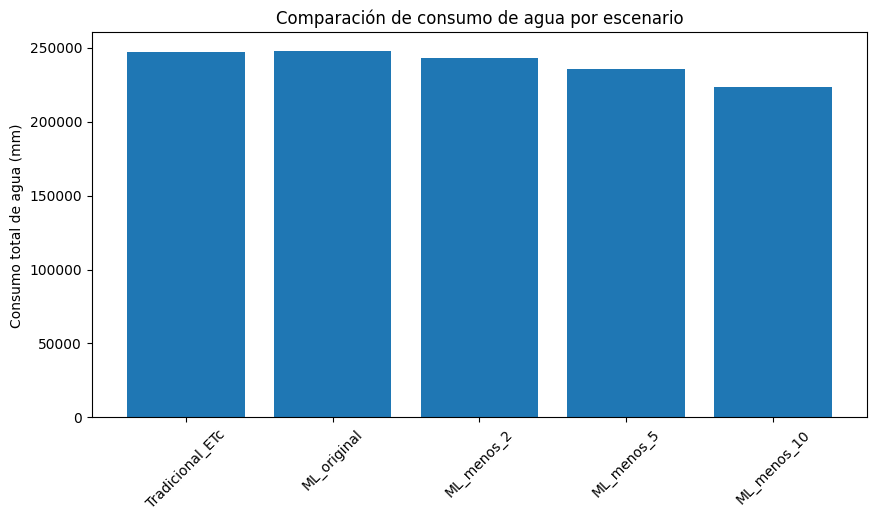

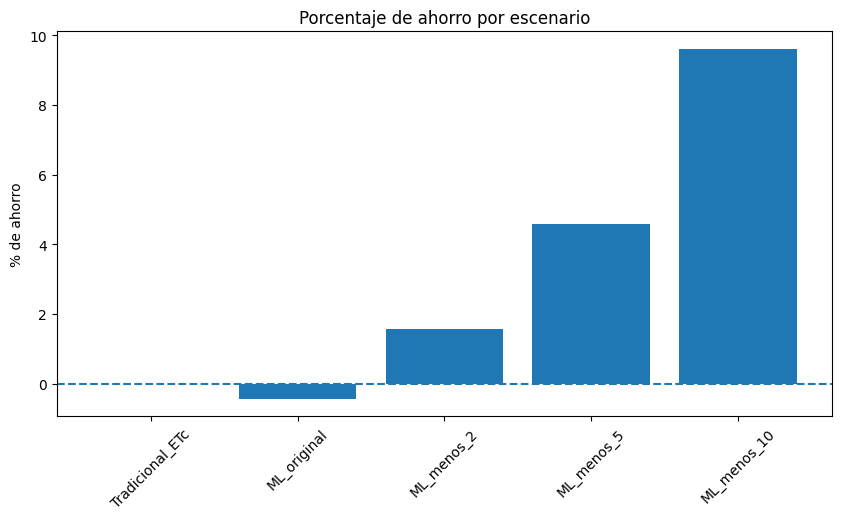

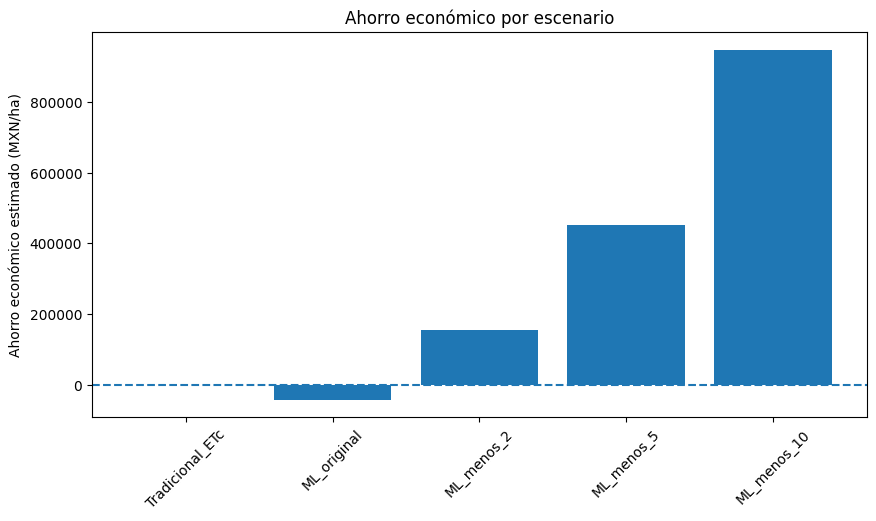

In [9]:
# Comparación de consumo
plt.figure(figsize=(10,5))
plt.bar(resultados_df["escenario"], resultados_df["consumo_total_mm"])
plt.xticks(rotation=45)
plt.ylabel("Consumo total de agua (mm)")
plt.title("Comparación de consumo de agua por escenario")
plt.show()

# Ahorro porcentual
plt.figure(figsize=(10,5))
plt.bar(resultados_df["escenario"], resultados_df["porcentaje_ahorro"])
plt.xticks(rotation=45)
plt.ylabel("% de ahorro")
plt.title("Porcentaje de ahorro por escenario")
plt.axhline(0, linestyle="--")
plt.show()

# Ahorro económico
plt.figure(figsize=(10,5))
plt.bar(resultados_df["escenario"], resultados_df["ahorro_mxn"])
plt.xticks(rotation=45)
plt.ylabel("Ahorro económico estimado (MXN/ha)")
plt.title("Ahorro económico por escenario")
plt.axhline(0, linestyle="--")
plt.show()
